# Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, f1_score, roc_auc_score)
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
import joblib
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_style('whitegrid')

# Load and explore

Shape: (233139, 2)

First 5 rows:
        Type                                Payload
0  traversal                          ../etc/passwd
1  traversal                           ../etc/issue
2  traversal                            ../boot.ini
3  traversal  ../windows/system32/drivers/etc/hosts
4  traversal                       ../../etc/passwd

Attack type distribution:
Type
benign       109158
cmdinj        69493
xss           33132
traversal     18497
sql            2729
ssti            130
Name: count, dtype: int64


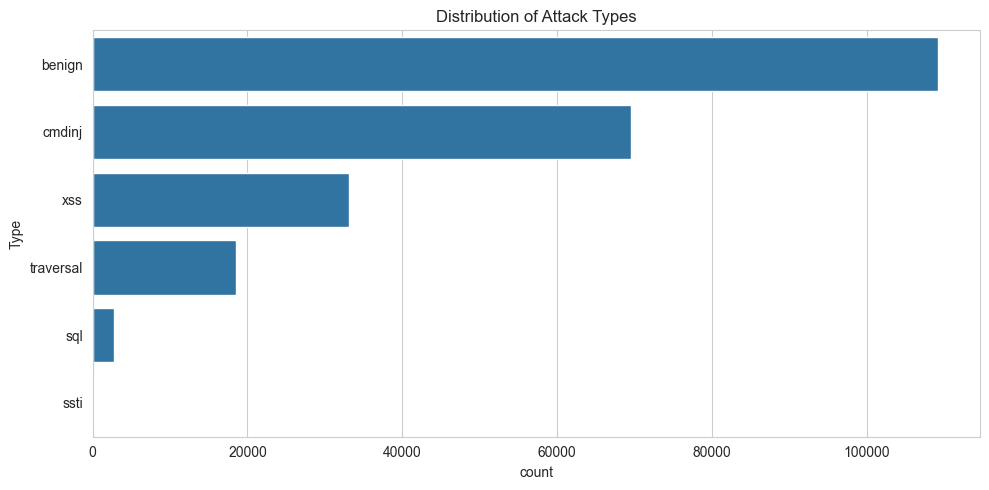

In [2]:
df = pd.read_csv('clean_payloads.csv')
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nAttack type distribution:")
print(df['Type'].value_counts())


plt.figure(figsize=(10,5))
sns.countplot(y='Type', data=df, order=df['Type'].value_counts().index)
plt.title('Distribution of Attack Types')
plt.tight_layout()
plt.show()

# Preprocessing

In [3]:
# Encode labels
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['Type'])
print("Label mapping:", dict(zip(le.classes_, range(len(le.classes_)))))

# Features and target
X = df['Payload'].values
y = df['label_encoded'].values

vectorizer = TfidfVectorizer(
    analyzer='char_wb',      # word‑boundary characters
    ngram_range=(3,6),       # n‑grams of length 3..6
    max_features=15000,
    sublinear_tf=True
)

X_vec = vectorizer.fit_transform(X)
print("Feature matrix shape:", X_vec.shape)

Label mapping: {'benign': 0, 'cmdinj': 1, 'sql': 2, 'ssti': 3, 'traversal': 4, 'xss': 5}
Feature matrix shape: (233139, 15000)


# Train & Evaluate

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_vec, y, test_size=0.2, random_state=42, stratify=y
)

print("Before SMOTE:", dict(zip(*np.unique(y_train, return_counts=True))))

# Handle very small classes for SMOTE
from collections import Counter
min_class_size = min(Counter(y_train).values())
if min_class_size <= 2:
    from imblearn.over_sampling import RandomOverSampler
    sampler = RandomOverSampler(random_state=42)
    print("Using RandomOverSampler due to tiny class")
elif min_class_size < 6:
    k = min_class_size - 1
    sampler = SMOTE(random_state=42, k_neighbors=k)
    print(f"Using SMOTE with k_neighbors={k}")
else:
    sampler = SMOTE(random_state=42)

X_train_res, y_train_res = sampler.fit_resample(X_train, y_train)
print("After sampling:", Counter(y_train_res))

Before SMOTE: {np.int64(0): np.int64(87326), np.int64(1): np.int64(55594), np.int64(2): np.int64(2183), np.int64(3): np.int64(104), np.int64(4): np.int64(14798), np.int64(5): np.int64(26506)}
After sampling: Counter({np.int64(0): 87326, np.int64(5): 87326, np.int64(1): 87326, np.int64(4): 87326, np.int64(2): 87326, np.int64(3): 87326})


# Model Training


In [5]:
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

param_grid = {
    'n_estimators': [150, 200, 250],
    'max_depth': [15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

random_search = RandomizedSearchCV(
    rf, param_grid, n_iter=15, cv=3, scoring='f1_macro',
    n_jobs=-1, random_state=42, verbose=2
)

random_search.fit(X_train_res, y_train_res)
best_rf = random_search.best_estimator_
print("Best parameters:", random_search.best_params_)
print("Best CV F1‑macro score:", random_search.best_score_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best parameters: {'n_estimators': 250, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': None}
Best CV F1‑macro score: 0.9827234484835873


# Evaluation on Test Set

Test Accuracy: 0.9689
Macro F1 Score: 0.8146

Detailed Classification Report:
              precision    recall  f1-score   support

      benign       1.00      0.94      0.97     21832
      cmdinj       1.00      1.00      1.00     13899
         sql       0.85      0.95      0.90       546
        ssti       0.02      0.85      0.03        26
   traversal       0.99      1.00      0.99      3699
         xss       1.00      0.99      0.99      6626

    accuracy                           0.97     46628
   macro avg       0.81      0.95      0.81     46628
weighted avg       0.99      0.97      0.98     46628



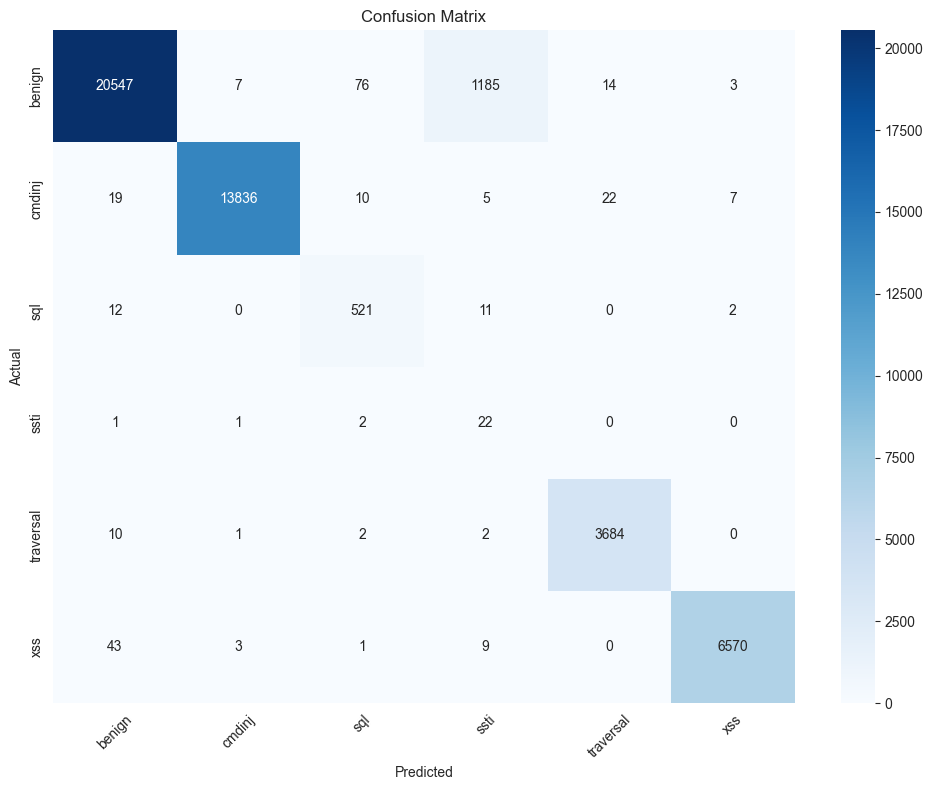

Macro‑average ROC‑AUC: 0.9948


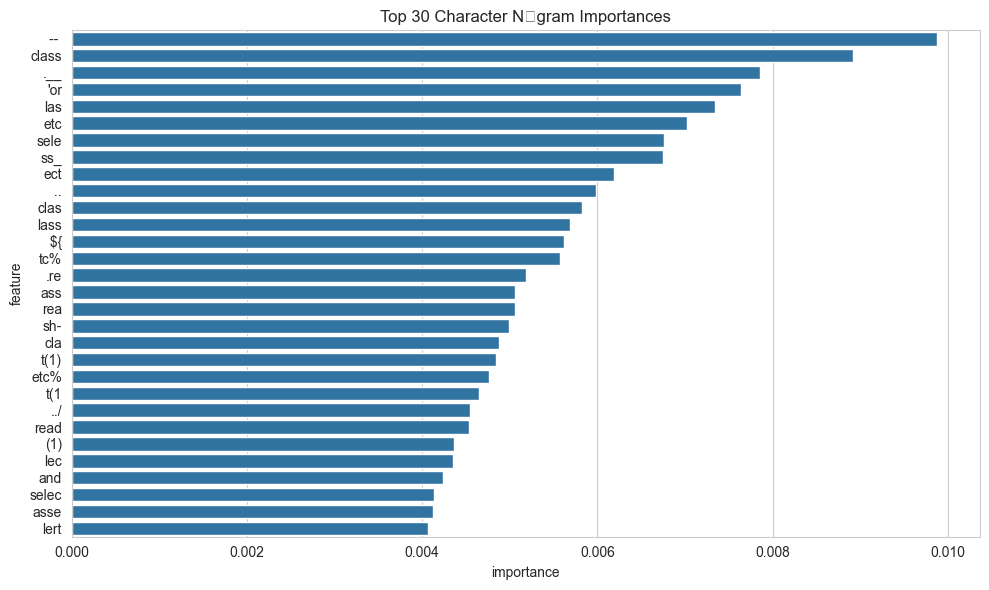

In [6]:
y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')
print(f"Test Accuracy: {acc:.4f}")
print(f"Macro F1 Score: {f1:.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

from sklearn.preprocessing import label_binarize
y_test_bin = label_binarize(y_test, classes=range(len(le.classes_)))
roc_auc = roc_auc_score(y_test_bin, y_proba, multi_class='ovr')
print(f"Macro‑average ROC‑AUC: {roc_auc:.4f}")

importances = best_rf.feature_importances_
# Get feature names from vectorizer
feature_names = vectorizer.get_feature_names_out()
imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
imp_df = imp_df.sort_values('importance', ascending=False).head(30)

plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=imp_df)
plt.title('Top 30 Character N‑gram Importances')
plt.tight_layout()
plt.show()

# Export Model, Vectorizer, and Label Encoder

In [7]:
import os
os.makedirs('Application_Attack_Detection/models', exist_ok=True)

joblib.dump(best_rf, 'Application_Attack_Detection/models/web_attack_rf.pkl')
joblib.dump(vectorizer, 'Application_Attack_Detection/models/tfidf_vectorizer.pkl')
joblib.dump(le, 'Application_Attack_Detection/models/label_encoder.pkl')

print("Model and artifacts saved to 'Application_Attack_Detection/models/'")

Model and artifacts saved to 'Application_Attack_Detection/models/'


# Inference Function (Ready for Raspberry Pi 5)

In [8]:
def detect_attack(payload):
    X = vectorizer.transform([payload])
    pred_id = best_rf.predict(X)[0]
    proba = best_rf.predict_proba(X)[0]
    return {
        'attack_type': le.inverse_transform([pred_id])[0],
        'confidence': float(proba.max()),
        'all_probabilities': dict(zip(le.classes_, proba))
    }

# Test with a sample
sample = "<script>alert('XSS')</script>"
result = detect_attack(sample)
print(result)

{'attack_type': 'xss', 'confidence': 0.9999902676399026, 'all_probabilities': {'benign': np.float64(0.0), 'cmdinj': np.float64(9.732360097323602e-06), 'sql': np.float64(0.0), 'ssti': np.float64(0.0), 'traversal': np.float64(0.0), 'xss': np.float64(0.9999902676399026)}}
